In [9]:
!pip install pycryptodome matplotlib

In [12]:
"""


Resources Used:
1. PyCryptodome Documentation: https://pycryptodome.readthedocs.io/
2. Python Cryptography Library: https://cryptography.io/en/latest/
3. RSA Implementation Guide: https://www.pycryptodome.org/en/latest/src/public_key/rsa.html
4. AES Modes Tutorial: https://www.pycryptodome.org/en/latest/src/cipher/aes.html
"""

import os
import time
import hashlib
from Crypto.Cipher import AES
from Crypto.PublicKey import RSA
from Crypto.Signature import pkcs1_15
from Crypto.Hash import SHA256
from Crypto.Random import get_random_bytes
from Crypto.Util.Padding import pad, unpad
import matplotlib.pyplot as plt

class CryptoLab:
    def __init__(self):
        self.aes_key_128 = None
        self.aes_key_256 = None
        self.rsa_key = None
        self.execution_times = []

    def generate_keys(self):
        """Generate and store all required keys"""
        print("Generating keys...")

        # Generate AES keys
        self.aes_key_128 = get_random_bytes(16)  # 128 bits
        self.aes_key_256 = get_random_bytes(32)  # 256 bits

        # Store AES keys
        with open('aes_128.key', 'wb') as f:
            f.write(self.aes_key_128)
        with open('aes_256.key', 'wb') as f:
            f.write(self.aes_key_256)

        # Generate RSA key pair (2048 bits)
        self.rsa_key = RSA.generate(2048)

        # Store RSA keys
        with open('rsa_private.pem', 'wb') as f:
            f.write(self.rsa_key.export_key())
        with open('rsa_public.pem', 'wb') as f:
            f.write(self.rsa_key.publickey().export_key())

        print("Keys generated and stored successfully!")
        print("- aes_128.key")
        print("- aes_256.key")
        print("- rsa_private.pem")
        print("- rsa_public.pem")

    def load_keys(self):
        """Load keys from files"""
        try:
            with open('aes_128.key', 'rb') as f:
                self.aes_key_128 = f.read()
            with open('aes_256.key', 'rb') as f:
                self.aes_key_256 = f.read()
            with open('rsa_private.pem', 'rb') as f:
                self.rsa_key = RSA.import_key(f.read())
            print("Keys loaded successfully!")
            return True
        except FileNotFoundError:
            print("Keys not found. Generating new keys...")
            self.generate_keys()
            return True

    # ==================== AES OPERATIONS ====================

    def aes_encrypt_ecb(self, plaintext, key_size=128):
        """AES Encryption in ECB mode"""
        key = self.aes_key_128 if key_size == 128 else self.aes_key_256
        cipher = AES.new(key, AES.MODE_ECB)

        start_time = time.time()
        padded_data = pad(plaintext.encode(), AES.block_size)
        ciphertext = cipher.encrypt(padded_data)
        end_time = time.time()

        # Save to file
        with open('aes_ecb_encrypted.bin', 'wb') as f:
            f.write(ciphertext)

        print(f"\n[AES-{key_size} ECB Encryption]")
        print(f"Encrypted data saved to: aes_ecb_encrypted.bin")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    def aes_decrypt_ecb(self, key_size=128):
        """AES Decryption in ECB mode"""
        key = self.aes_key_128 if key_size == 128 else self.aes_key_256

        with open('aes_ecb_encrypted.bin', 'rb') as f:
            ciphertext = f.read()

        cipher = AES.new(key, AES.MODE_ECB)

        start_time = time.time()
        decrypted_padded = cipher.decrypt(ciphertext)
        plaintext = unpad(decrypted_padded, AES.block_size)
        end_time = time.time()

        print(f"\n[AES-{key_size} ECB Decryption]")
        print(f"Decrypted text: {plaintext.decode()}")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    def aes_encrypt_cfb(self, plaintext, key_size=128):
        """AES Encryption in CFB mode"""
        key = self.aes_key_128 if key_size == 128 else self.aes_key_256
        iv = get_random_bytes(16)
        cipher = AES.new(key, AES.MODE_CFB, iv)

        start_time = time.time()
        ciphertext = cipher.encrypt(plaintext.encode())
        end_time = time.time()

        # Save IV and ciphertext
        with open('aes_cfb_encrypted.bin', 'wb') as f:
            f.write(iv + ciphertext)

        print(f"\n[AES-{key_size} CFB Encryption]")
        print(f"Encrypted data saved to: aes_cfb_encrypted.bin")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    def aes_decrypt_cfb(self, key_size=128):
        """AES Decryption in CFB mode"""
        key = self.aes_key_128 if key_size == 128 else self.aes_key_256

        with open('aes_cfb_encrypted.bin', 'rb') as f:
            data = f.read()

        iv = data[:16]
        ciphertext = data[16:]
        cipher = AES.new(key, AES.MODE_CFB, iv)

        start_time = time.time()
        plaintext = cipher.decrypt(ciphertext)
        end_time = time.time()

        print(f"\n[AES-{key_size} CFB Decryption]")
        print(f"Decrypted text: {plaintext.decode()}")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    # ==================== RSA OPERATIONS ====================

    def rsa_encrypt(self, plaintext):
        """RSA Encryption"""
        from Crypto.Cipher import PKCS1_OAEP

        public_key = self.rsa_key.publickey()
        cipher = PKCS1_OAEP.new(public_key)

        start_time = time.time()
        ciphertext = cipher.encrypt(plaintext.encode())
        end_time = time.time()

        with open('rsa_encrypted.bin', 'wb') as f:
            f.write(ciphertext)

        print(f"\n[RSA Encryption]")
        print(f"Encrypted data saved to: rsa_encrypted.bin")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    def rsa_decrypt(self):
        """RSA Decryption"""
        from Crypto.Cipher import PKCS1_OAEP

        with open('rsa_encrypted.bin', 'rb') as f:
            ciphertext = f.read()

        cipher = PKCS1_OAEP.new(self.rsa_key)

        start_time = time.time()
        plaintext = cipher.decrypt(ciphertext)
        end_time = time.time()

        print(f"\n[RSA Decryption]")
        print(f"Decrypted text: {plaintext.decode()}")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    # ==================== RSA SIGNATURE ====================

    def rsa_sign(self, filename):
        """Generate RSA signature for a file"""
        with open(filename, 'rb') as f:
            data = f.read()

        hash_obj = SHA256.new(data)

        start_time = time.time()
        signature = pkcs1_15.new(self.rsa_key).sign(hash_obj)
        end_time = time.time()

        with open(filename + '.sig', 'wb') as f:
            f.write(signature)

        print(f"\n[RSA Signature]")
        print(f"Signature saved to: {filename}.sig")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    def rsa_verify(self, filename, signature_file):
        """Verify RSA signature"""
        with open(filename, 'rb') as f:
            data = f.read()
        with open(signature_file, 'rb') as f:
            signature = f.read()

        hash_obj = SHA256.new(data)
        public_key = self.rsa_key.publickey()

        start_time = time.time()
        try:
            pkcs1_15.new(public_key).verify(hash_obj, signature)
            verified = True
        except (ValueError, TypeError):
            verified = False
        end_time = time.time()

        print(f"\n[RSA Signature Verification]")
        print(f"Verification result: {'VALID' if verified else 'INVALID'}")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    # ==================== SHA-256 HASHING ====================

    def sha256_hash(self, filename):
        """Generate SHA-256 hash of a file"""
        with open(filename, 'rb') as f:
            data = f.read()

        start_time = time.time()
        hash_obj = hashlib.sha256(data)
        hash_hex = hash_obj.hexdigest()
        end_time = time.time()

        print(f"\n[SHA-256 Hash]")
        print(f"File: {filename}")
        print(f"Hash: {hash_hex}")
        print(f"Execution time: {end_time - start_time:.6f} seconds")

        return end_time - start_time

    # ==================== PERFORMANCE ANALYSIS ====================

    def performance_analysis(self):
        """Measure execution time for different key sizes"""
        print("\n" + "="*60)
        print("PERFORMANCE ANALYSIS")
        print("="*60)

        # Test data of different sizes
        test_sizes = [16, 32, 64, 128, 256]  # bits
        aes_128_times = []
        aes_256_times = []

        print("\nTesting AES encryption with different data sizes...")
        for size in test_sizes:
            data = "A" * (size * 8)  # More data for better timing

            # AES-128
            key = get_random_bytes(16)
            cipher = AES.new(key, AES.MODE_ECB)
            start = time.time()
            cipher.encrypt(pad(data.encode(), AES.block_size))
            aes_128_times.append(time.time() - start)

            # AES-256
            key = get_random_bytes(32)
            cipher = AES.new(key, AES.MODE_ECB)
            start = time.time()
            cipher.encrypt(pad(data.encode(), AES.block_size))
            aes_256_times.append(time.time() - start)

        # RSA with different key sizes (minimum 1024 bits)
        rsa_key_sizes = [1024, 1536, 2048, 3072, 4096]
        rsa_gen_times = []
        rsa_enc_times = []

        print("Testing RSA with different key sizes...")
        for key_size in rsa_key_sizes:
            print(f"  Testing RSA-{key_size}...")

            # Measure key generation time
            start = time.time()
            rsa_key = RSA.generate(key_size)
            rsa_gen_times.append(time.time() - start)

            # Measure encryption time
            from Crypto.Cipher import PKCS1_OAEP
            cipher = PKCS1_OAEP.new(rsa_key.publickey())
            data = b"Test message for encryption"
            start = time.time()
            cipher.encrypt(data)
            rsa_enc_times.append(time.time() - start)

        # Plotting
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

        # AES Plot
        ax1.plot(test_sizes, aes_128_times, marker='o', label='AES-128', linewidth=2, markersize=8)
        ax1.plot(test_sizes, aes_256_times, marker='s', label='AES-256', linewidth=2, markersize=8)
        ax1.set_xlabel('Data Size (bits)', fontsize=12)
        ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
        ax1.set_title('AES Encryption Performance', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)

        # RSA Key Generation Plot
        ax2.plot(rsa_key_sizes, rsa_gen_times, marker='o', color='green', linewidth=2, markersize=8)
        ax2.set_xlabel('RSA Key Size (bits)', fontsize=12)
        ax2.set_ylabel('Execution Time (seconds)', fontsize=12)
        ax2.set_title('RSA Key Generation Performance', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)

        # RSA Encryption Plot
        ax3.plot(rsa_key_sizes, rsa_enc_times, marker='s', color='red', linewidth=2, markersize=8)
        ax3.set_xlabel('RSA Key Size (bits)', fontsize=12)
        ax3.set_ylabel('Execution Time (seconds)', fontsize=12)
        ax3.set_title('RSA Encryption Performance', fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('performance_analysis.png', dpi=300, bbox_inches='tight')
        print("\n✓ Performance graph saved as: performance_analysis.png")
        plt.show()

        # Print detailed results
        print("\n" + "="*60)
        print("DETAILED RESULTS")
        print("="*60)
        print("\nAES Performance:")
        print(f"{'Data Size (bits)':<20} {'AES-128 (s)':<15} {'AES-256 (s)':<15}")
        print("-" * 50)
        for i, size in enumerate(test_sizes):
            print(f"{size:<20} {aes_128_times[i]:<15.8f} {aes_256_times[i]:<15.8f}")

        print("\nRSA Performance:")
        print(f"{'Key Size (bits)':<20} {'Generation (s)':<20} {'Encryption (s)':<20}")
        print("-" * 60)
        for i, size in enumerate(rsa_key_sizes):
            print(f"{size:<20} {rsa_gen_times[i]:<20.8f} {rsa_enc_times[i]:<20.8f}")

        return {
            'aes_128': list(zip(test_sizes, aes_128_times)),
            'aes_256': list(zip(test_sizes, aes_256_times)),
            'rsa_generation': list(zip(rsa_key_sizes, rsa_gen_times)),
            'rsa_encryption': list(zip(rsa_key_sizes, rsa_enc_times))
        }

def main():
    """Main menu-driven program"""
    crypto = CryptoLab()
    crypto.load_keys()

    while True:
        print("\n" + "="*60)
        print("INS LAB")
        print("="*60)
        print("1.  AES-128 Encryption (ECB)")
        print("2.  AES-128 Decryption (ECB)")
        print("3.  AES-128 Encryption (CFB)")
        print("4.  AES-128 Decryption (CFB)")
        print("5.  AES-256 Encryption (ECB)")
        print("6.  AES-256 Decryption (ECB)")
        print("7.  AES-256 Encryption (CFB)")
        print("8.  AES-256 Decryption (CFB)")
        print("9.  RSA Encryption")
        print("10. RSA Decryption")
        print("11. RSA Sign File")
        print("12. RSA Verify Signature")
        print("13. SHA-256 Hash File")
        print("14. Performance Analysis")
        print("15. Regenerate Keys")
        print("0.  Exit")
        print("="*60)

        choice = input("\nEnter your choice: ").strip()

        if choice == '0':
            print("Exiting... Goodbye!")
            break

        elif choice == '1':
            text = input("Enter text to encrypt: ")
            crypto.aes_encrypt_ecb(text, 128)

        elif choice == '2':
            crypto.aes_decrypt_ecb(128)

        elif choice == '3':
            text = input("Enter text to encrypt: ")
            crypto.aes_encrypt_cfb(text, 128)

        elif choice == '4':
            crypto.aes_decrypt_cfb(128)

        elif choice == '5':
            text = input("Enter text to encrypt: ")
            crypto.aes_encrypt_ecb(text, 256)

        elif choice == '6':
            crypto.aes_decrypt_ecb(256)

        elif choice == '7':
            text = input("Enter text to encrypt: ")
            crypto.aes_encrypt_cfb(text, 256)

        elif choice == '8':
            crypto.aes_decrypt_cfb(256)

        elif choice == '9':
            text = input("Enter text to encrypt (max 190 chars): ")
            crypto.rsa_encrypt(text)

        elif choice == '10':
            crypto.rsa_decrypt()

        elif choice == '11':
            filename = input("Enter filename to sign: ")
            if os.path.exists(filename):
                crypto.rsa_sign(filename)
            else:
                print(f"File '{filename}' not found!")

        elif choice == '12':
            filename = input("Enter filename: ")
            sig_file = input("Enter signature filename: ")
            if os.path.exists(filename) and os.path.exists(sig_file):
                crypto.rsa_verify(filename, sig_file)
            else:
                print("File(s) not found!")

        elif choice == '13':
            filename = input("Enter filename to hash: ")
            if os.path.exists(filename):
                crypto.sha256_hash(filename)
            else:
                print(f"File '{filename}' not found!")

        elif choice == '14':
            crypto.performance_analysis()

        elif choice == '15':
            crypto.generate_keys()

        else:
            print("Invalid choice! Please try again.")

if __name__ == "__main__":
    main()

Keys loaded successfully!

INS LAB
1.  AES-128 Encryption (ECB)
2.  AES-128 Decryption (ECB)
3.  AES-128 Encryption (CFB)
4.  AES-128 Decryption (CFB)
5.  AES-256 Encryption (ECB)
6.  AES-256 Decryption (ECB)
7.  AES-256 Encryption (CFB)
8.  AES-256 Decryption (CFB)
9.  RSA Encryption
10. RSA Decryption
11. RSA Sign File
12. RSA Verify Signature
13. SHA-256 Hash File
14. Performance Analysis
15. Regenerate Keys
0.  Exit

Enter your choice: 1
Enter text to encrypt: I am Jerry

[AES-128 ECB Encryption]
Encrypted data saved to: aes_ecb_encrypted.bin
Execution time: 0.000031 seconds

INS LAB
1.  AES-128 Encryption (ECB)
2.  AES-128 Decryption (ECB)
3.  AES-128 Encryption (CFB)
4.  AES-128 Decryption (CFB)
5.  AES-256 Encryption (ECB)
6.  AES-256 Decryption (ECB)
7.  AES-256 Encryption (CFB)
8.  AES-256 Decryption (CFB)
9.  RSA Encryption
10. RSA Decryption
11. RSA Sign File
12. RSA Verify Signature
13. SHA-256 Hash File
14. Performance Analysis
15. Regenerate Keys
0.  Exit

Enter your choi


               CRYPTOGRAPHY PERFORMANCE ANALYZER

This tool analyzes the performance of AES and RSA algorithms
with different key sizes and generates comprehensive reports.

AES PERFORMANCE ANALYSIS

Testing AES encryption...
  Data size: 16 bits (128 bytes)
  Data size: 32 bits (256 bytes)
  Data size: 64 bits (512 bytes)
  Data size: 128 bits (1024 bytes)
  Data size: 256 bits (2048 bytes)

RSA PERFORMANCE ANALYSIS

Testing RSA operations...
  Key size: 1024 bits
  Key size: 1536 bits
  Key size: 2048 bits
  Key size: 3072 bits
  Key size: 4096 bits

Generating performance graphs...

✓ Performance graphs saved as: crypto_performance_analysis.png


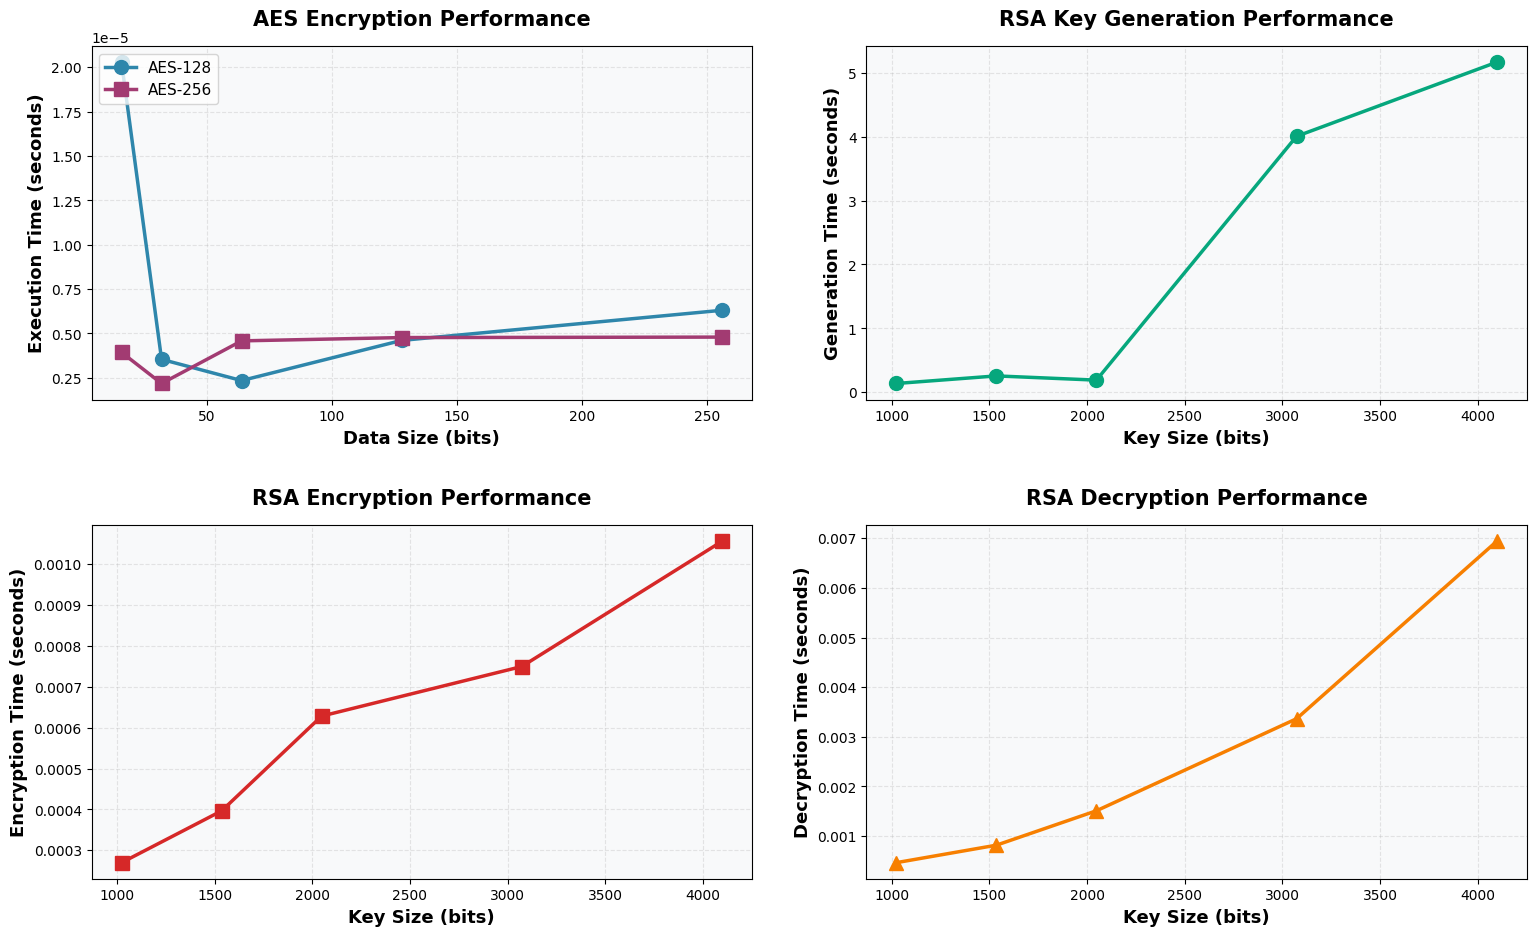


DETAILED PERFORMANCE RESULTS

----------------------------------------------------------------------
AES ENCRYPTION PERFORMANCE
----------------------------------------------------------------------
Data Size (bits)     AES-128 (s)          AES-256 (s)         
----------------------------------------------------------------------
16                   0.0000202870         0.0000039291        
32                   0.0000035357         0.0000021744        
64                   0.0000023389         0.0000045776        
128                  0.0000046039         0.0000047636        
256                  0.0000063014         0.0000047898        

Observation: AES-256 is approximately -8.79% slower than AES-128

----------------------------------------------------------------------
RSA PERFORMANCE
----------------------------------------------------------------------
Key Size     Generation (s)     Encryption (s)     Decryption (s)    
--------------------------------------------------------

In [11]:
"""

Resources:
- PyCryptodome Documentation: https://pycryptodome.readthedocs.io/
"""

import time
from Crypto.Cipher import AES
from Crypto.PublicKey import RSA
from Crypto.Random import get_random_bytes
from Crypto.Util.Padding import pad
import matplotlib.pyplot as plt

def analyze_aes_performance():
    """Analyze AES encryption performance with different data sizes"""
    print("="*70)
    print("AES PERFORMANCE ANALYSIS")
    print("="*70)

    # Test with different data sizes (in bits)
    data_sizes = [16, 32, 64, 128, 256]
    aes_128_times = []
    aes_256_times = []

    print("\nTesting AES encryption...")
    for size in data_sizes:
        # Create test data (size * 8 bytes for better timing)
        test_data = "A" * (size * 8)
        print(f"  Data size: {size} bits ({len(test_data)} bytes)")

        # Test AES-128
        key_128 = get_random_bytes(16)
        cipher_128 = AES.new(key_128, AES.MODE_ECB)

        start = time.time()
        for _ in range(100):  # Run 100 times for better accuracy
            cipher_128.encrypt(pad(test_data.encode(), AES.block_size))
        elapsed_128 = (time.time() - start) / 100
        aes_128_times.append(elapsed_128)

        # Test AES-256
        key_256 = get_random_bytes(32)
        cipher_256 = AES.new(key_256, AES.MODE_ECB)

        start = time.time()
        for _ in range(100):  # Run 100 times for better accuracy
            cipher_256.encrypt(pad(test_data.encode(), AES.block_size))
        elapsed_256 = (time.time() - start) / 100
        aes_256_times.append(elapsed_256)

    return data_sizes, aes_128_times, aes_256_times

def analyze_rsa_performance():
    """Analyze RSA performance with different key sizes"""
    print("\n" + "="*70)
    print("RSA PERFORMANCE ANALYSIS")
    print("="*70)

    # RSA key sizes (minimum 1024 bits as per PyCryptodome requirement)
    key_sizes = [1024, 1536, 2048, 3072, 4096]
    generation_times = []
    encryption_times = []
    decryption_times = []

    test_message = b"This is a test message for RSA encryption performance analysis"

    print("\nTesting RSA operations...")
    for key_size in key_sizes:
        print(f"  Key size: {key_size} bits")

        # Measure key generation time
        start = time.time()
        rsa_key = RSA.generate(key_size)
        gen_time = time.time() - start
        generation_times.append(gen_time)

        # Measure encryption time
        from Crypto.Cipher import PKCS1_OAEP
        public_key = rsa_key.publickey()
        cipher_enc = PKCS1_OAEP.new(public_key)

        start = time.time()
        for _ in range(10):  # Run 10 times
            ciphertext = cipher_enc.encrypt(test_message)
        enc_time = (time.time() - start) / 10
        encryption_times.append(enc_time)

        # Measure decryption time
        cipher_dec = PKCS1_OAEP.new(rsa_key)

        start = time.time()
        for _ in range(10):  # Run 10 times
            cipher_dec.decrypt(ciphertext)
        dec_time = (time.time() - start) / 10
        decryption_times.append(dec_time)

    return key_sizes, generation_times, encryption_times, decryption_times

def plot_results(aes_data, rsa_data):
    """Create comprehensive performance plots"""
    data_sizes, aes_128_times, aes_256_times = aes_data
    key_sizes, gen_times, enc_times, dec_times = rsa_data

    # Create figure with 4 subplots
    fig = plt.figure(figsize=(16, 10))

    # 1. AES Encryption Performance
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(data_sizes, aes_128_times, marker='o', label='AES-128',
             linewidth=2.5, markersize=10, color='#2E86AB')
    ax1.plot(data_sizes, aes_256_times, marker='s', label='AES-256',
             linewidth=2.5, markersize=10, color='#A23B72')
    ax1.set_xlabel('Data Size (bits)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Execution Time (seconds)', fontsize=13, fontweight='bold')
    ax1.set_title('AES Encryption Performance', fontsize=15, fontweight='bold', pad=15)
    ax1.legend(fontsize=11, loc='upper left')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_facecolor('#F8F9FA')

    # 2. RSA Key Generation
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(key_sizes, gen_times, marker='o', linewidth=2.5,
             markersize=10, color='#06A77D')
    ax2.set_xlabel('Key Size (bits)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Generation Time (seconds)', fontsize=13, fontweight='bold')
    ax2.set_title('RSA Key Generation Performance', fontsize=15, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_facecolor('#F8F9FA')

    # 3. RSA Encryption
    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(key_sizes, enc_times, marker='s', linewidth=2.5,
             markersize=10, color='#D62828')
    ax3.set_xlabel('Key Size (bits)', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Encryption Time (seconds)', fontsize=13, fontweight='bold')
    ax3.set_title('RSA Encryption Performance', fontsize=15, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_facecolor('#F8F9FA')

    # 4. RSA Decryption
    ax4 = plt.subplot(2, 2, 4)
    ax4.plot(key_sizes, dec_times, marker='^', linewidth=2.5,
             markersize=10, color='#F77F00')
    ax4.set_xlabel('Key Size (bits)', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Decryption Time (seconds)', fontsize=13, fontweight='bold')
    ax4.set_title('RSA Decryption Performance', fontsize=15, fontweight='bold', pad=15)
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_facecolor('#F8F9FA')

    plt.tight_layout(pad=3.0)
    plt.savefig('crypto_performance_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Performance graphs saved as: crypto_performance_analysis.png")
    plt.show()

def print_detailed_results(aes_data, rsa_data):
    """Print detailed numerical results"""
    data_sizes, aes_128_times, aes_256_times = aes_data
    key_sizes, gen_times, enc_times, dec_times = rsa_data

    print("\n" + "="*70)
    print("DETAILED PERFORMANCE RESULTS")
    print("="*70)

    # AES Results
    print("\n" + "-"*70)
    print("AES ENCRYPTION PERFORMANCE")
    print("-"*70)
    print(f"{'Data Size (bits)':<20} {'AES-128 (s)':<20} {'AES-256 (s)':<20}")
    print("-"*70)
    for i, size in enumerate(data_sizes):
        print(f"{size:<20} {aes_128_times[i]:<20.10f} {aes_256_times[i]:<20.10f}")

    # AES Comparison
    print("\nObservation: AES-256 is approximately", end=" ")
    avg_ratio = sum([aes_256_times[i]/aes_128_times[i] for i in range(len(data_sizes))]) / len(data_sizes)
    print(f"{(avg_ratio-1)*100:.2f}% slower than AES-128")

    # RSA Results
    print("\n" + "-"*70)
    print("RSA PERFORMANCE")
    print("-"*70)
    print(f"{'Key Size':<12} {'Generation (s)':<18} {'Encryption (s)':<18} {'Decryption (s)':<18}")
    print("-"*70)
    for i, size in enumerate(key_sizes):
        print(f"{size:<12} {gen_times[i]:<18.8f} {enc_times[i]:<18.10f} {dec_times[i]:<18.10f}")

    # RSA Observations
    print("\nObservations:")
    print(f"  • RSA-4096 key generation is {gen_times[-1]/gen_times[0]:.2f}x slower than RSA-1024")
    print(f"  • Decryption is approximately {dec_times[0]/enc_times[0]:.2f}x slower than encryption")
    print(f"  • RSA is approximately {enc_times[0]/aes_128_times[0]:.0f}x slower than AES")

def main():
    """Main execution function"""
    print("\n" + "="*70)
    print(" "*15 + "CRYPTOGRAPHY PERFORMANCE ANALYZER")
    print("="*70)
    print("\nThis tool analyzes the performance of AES and RSA algorithms")
    print("with different key sizes and generates comprehensive reports.\n")

    # Run analyses
    aes_data = analyze_aes_performance()
    rsa_data = analyze_rsa_performance()

    # Generate plots
    print("\nGenerating performance graphs...")
    plot_results(aes_data, rsa_data)

    # Print detailed results
    print_detailed_results(aes_data, rsa_data)

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE!")
    print("="*70)
    print("\nFiles generated:")
    print("  ✓ crypto_performance_analysis.png - Performance graphs")
    print("\nYou can include these results in your lab report.")

if __name__ == "__main__":
    main()